In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from lobster import *

In [3]:
ticker = "INTC"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
#[["type", "lvl", "size", "P_1", "Q_1", "P_-1", "Q_-1", "P_2", "Q_2", "P_-2", "Q_-2", "P_3", "Q_3", "P_-3", "Q_-3", "P_4", "Q_4", "P_-4", "Q_-4", "P_5", "Q_5", "P_-5", "Q_-5"]]
series = (df.groupby("type")["time"].count())/df.__len__()
display(series)
print(df.__len__())
display(df.groupby("type")[["dtk", "dtk_l"]].mean())
display(df[8000:8050])

type
C    0.456694
L    0.487336
M    0.055970
Name: time, dtype: float64

580351


,dtk,dtk_l
type,,
C,0.045963,0.404649
L,0.037143,0.393698
M,0.021950,0.071530


,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
8000,34267.147304,3.695540e-03,1.082608e-02,C,275500,-1,100,275550.0,275600.0,700,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8001,34267.155536,8.232246e-03,8.232246e-03,C,275500,-1,500,275550.0,275600.0,700,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8002,34267.155599,6.227500e-05,6.227500e-05,C,275500,-1,100,275550.0,275600.0,700,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8003,34267.209680,5.408197e-02,7.379736e-02,L,275600,1,100,275550.0,275600.0,800,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8004,34267.209696,1.563600e-05,1.563600e-05,L,275600,1,100,275550.0,275600.0,900,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8005,34267.209796,9.959200e-05,9.959200e-05,C,275600,1,100,275550.0,275600.0,800,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8006,34267.210178,3.827800e-04,5.457997e-02,C,275500,-1,400,275550.0,275600.0,800,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8007,34267.210291,1.129730e-04,4.957530e-04,L,275600,1,400,275550.0,275600.0,1200,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8008,34267.210359,6.759100e-05,1.805640e-04,C,275500,-1,300,275550.0,275600.0,1200,...,800,275900.0,1400,275200.0,1000,276000.0,3298,275100.0,1400,55
8009,34267.210817,4.581520e-04,6.720875e-02,C,275200,-4,100,275550.0,275600.0,1200,...,800,275900.0,1400,275200.0,900,276000.0,3298,275100.0,1400,55


In [4]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,197.19,162.42,324.82,483.88,119.1
2,40.20,59.75,0.00,441.55,462.3
3,22.71,22.55,0.00,451.23,1004.4
4,13.23,11.88,0.00,475.07,1672.0
5,9.50,8.44,0.00,596.93,2263.0


In [5]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
5,34200.049011,0.000022,0.042770,L,274900,-3,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
6,34200.049078,0.000068,0.042837,L,274800,-4,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,1,1
7,34200.049110,0.000032,0.042869,L,274700,-5,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
8,34200.049301,0.000190,0.000311,L,275000,-2,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
9,34200.211338,0.162038,0.205097,M,275200,1,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1


### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [6]:
df_train = df_norm.copy()

# 1) event id
event_map = {"L": 0, "C": 1, "M": 2}
df_train["event_id"] = df_train["type"].map(event_map).astype("int64")

# 2) hour of last event at the same level
df_train["hour_last_event"] = (df_train.groupby("lvl")["time"].shift(1) // 3600)

# 3) last event id at the same level
df_train["last_event_id"] = (df_train.groupby("lvl")["event_id"].shift(1))

# 4) pre-event queues within each constant-pref segment
def _q_event_row(row):
    idx = row.name
    if idx == 0:
        return np.nan 
    prev = df_train.iloc[idx - 1]  # previous row
    l = int(row["lvl"])
    if l == 0:
        return np.nan
    return prev[f"Q_{l}"]
df_train["q_before_event"] = df_train.apply(_q_event_row, axis=1).astype("float64")

# 5) clean dataframe of nan
df_train = df_train.dropna().reset_index(drop=True)
df_train[["q_before_event", "last_event_id"]] = df_train[["q_before_event", "last_event_id"]].astype("int64")
hour_map = {h: i for i, h in enumerate(sorted(df_train["hour_last_event"].unique()))}
df_train["hour_last_event"] = df_train["hour_last_event"].map(hour_map)

# 5) keep only what you need
df_train = df_train[["event_id", "lvl", "size", "dtk_l", "q_before_event", "last_event_id", "hour_last_event"]].copy()
df_train

,event_id,lvl,size,dtk_l,q_before_event,last_event_id,hour_last_event
0,0,-2,1,0.000125,0,1,0
1,0,-2,1,0.000311,1,0,0
2,2,1,1,0.205097,1,0,0
3,2,1,1,0.000000,1,2,0
4,2,1,1,0.000000,0,2,0
...,...,...,...,...,...,...,...
580336,1,1,72,0.011408,254,0,6
580337,0,-2,38,0.223738,71,1,6
580338,1,3,2,0.249387,244,1,6
580339,0,1,1,0.079201,183,1,6


### QR Model Intensities ###

In [7]:
from qrFunctions import shift_orderbook_before_event, build_all_sequences, estimate_all_qr
df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)
seqs = build_all_sequences(df_qr, K=5)
lambdas, Ns, Ts = estimate_all_qr(seqs)

In [8]:
from qrFunctions import qr_transition_matrix
qr_matrix = qr_transition_matrix(Ns, K=K)
qr_matrix

,cancel,limit,trade
cancel,0.456695,0.487335,0.05597
limit,0.456695,0.487335,0.05597
trade,0.456695,0.487335,0.05597


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [9]:
from dqrfunctions import build_dataset

data_vanilla = build_dataset(df_train, use_hour=False, use_last_event=False)
data_hour = build_dataset(df_train, use_hour=True, use_last_event=False)
data_last_event = build_dataset(df_train, use_hour=False, use_last_event=True)
data_hour_last_event = build_dataset(df_train, use_hour=True, use_last_event=True)

display(data_hour_last_event)

{'q': tensor([  0.,   1.,   1.,  ..., 244., 183.,  15.]),
 'y': tensor([0, 0, 2,  ..., 1, 0, 2]),
 'dt': tensor([1.2541e-04, 3.1128e-04, 2.0510e-01,  ..., 2.4939e-01, 7.9201e-02,
         3.1155e-01]),
 'last_event': tensor([1, 0, 0,  ..., 1, 1, 1]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [10]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [11]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [12]:
from dqrfunctions import train_model, get_or_train_model

### Vanilla Model ###

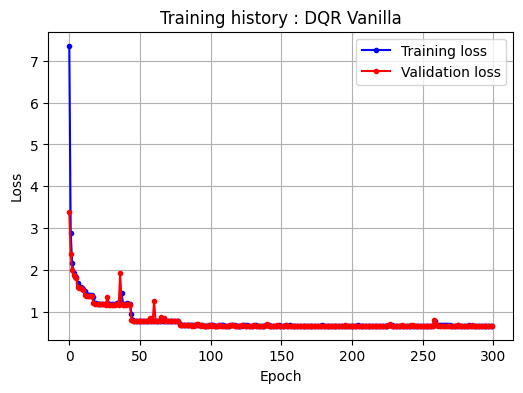

In [13]:
model_vanilla = get_or_train_model(
    f"models/{ticker}/dqr_vanilla.pt",
    data=data_vanilla,
    compute_model=False,
    use_hour=False,
    use_last_event=False)
model_vanilla.plot_history(model_name="Vanilla")

### Hour Model ###

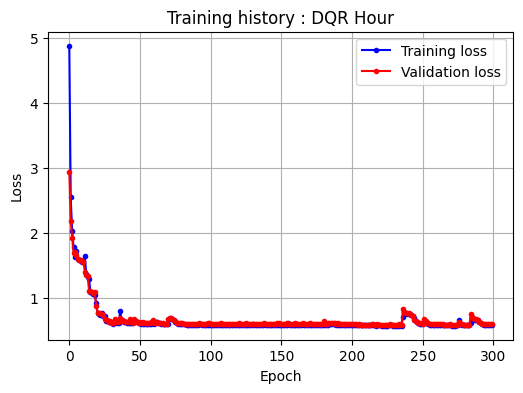

In [14]:
model_hour = get_or_train_model(
    f"models/{ticker}/dqr_hour.pt",
    data=data_hour,
    compute_model=False,
    use_hour=True,
    use_last_event=False,
    hour_num_classes=df_train["hour_last_event"].nunique())
model_hour.plot_history(model_name="Hour")

### Last-Event Model ###

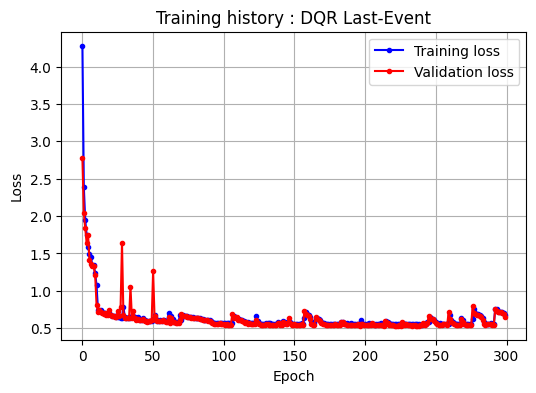

In [15]:
model_last_event = get_or_train_model(
    f"models/{ticker}/dqr_last_event.pt",
    data=data_last_event,
    compute_model=False,
    use_hour=False,
    use_last_event=True)
model_last_event.plot_history(model_name="Last-Event")

### Hour + Last-Event Model ###

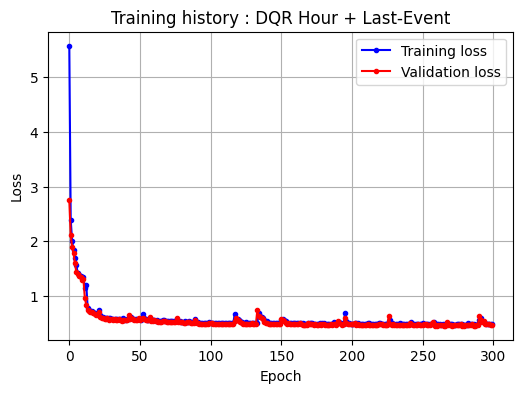

In [16]:
model_hour_last_event = get_or_train_model(
    f"models/{ticker}/dqr_hour_last_event.pt",
    data=data_hour_last_event,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=df_train["hour_last_event"].nunique())
model_hour_last_event.plot_history(model_name="Hour + Last-Event")

In [17]:
from dqrfunctions import transition_real, transition_dqr

event_id_np = df_train["event_id"].to_numpy()
last_id_np  = df_train["last_event_id"].to_numpy()
# DQR: last_event_id must match X lines format (torch)
last_id_t = torch.tensor(last_id_np, dtype=torch.long)

T_real = transition_real(event_id_np, last_id_np, n_events=3)
T_dqr_le = transition_dqr(
                        model=model_last_event,
                        data=data_last_event,
                        last_event_id=last_id_t,
                        n_events=3)
T_dqr_h_le = transition_dqr(
                        model=model_hour_last_event,
                        data=data_hour_last_event,
                        last_event_id=last_id_t,
                        n_events=3)
T_qr = qr_matrix.to_numpy()

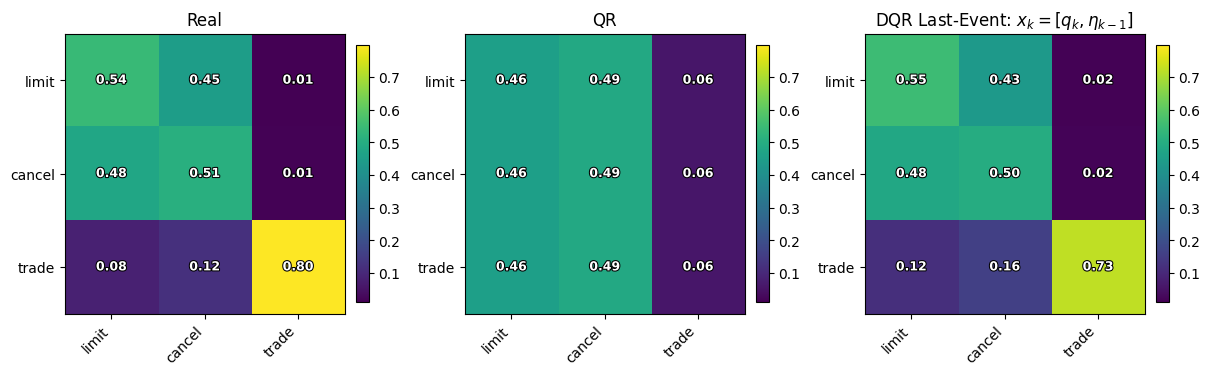

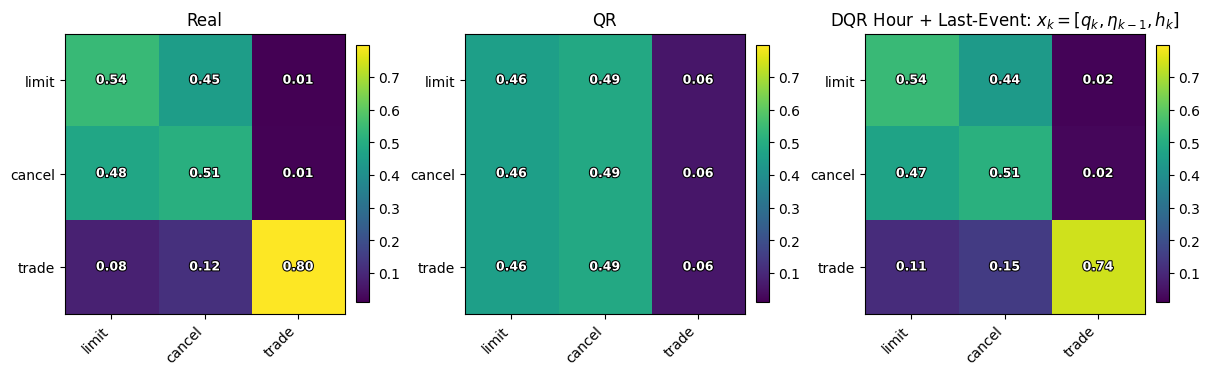

In [18]:
from dqrfunctions import plot_two_heatmaps, plot_three_heatmaps

EVENT_NAMES = ["limit", "cancel", "trade"]
dqr_last_event_title = r"DQR Last-Event: $x_k=[q_k,\eta_{k-1}]$"
dqr_hour_last_event_title = r"DQR Hour + Last-Event: $x_k=[q_k,\eta_{k-1},h_k]$"

fig = plot_three_heatmaps(T_real, T_qr, T_dqr_le, labels=EVENT_NAMES, dqr_title=dqr_last_event_title)
plt.show()
fig = plot_three_heatmaps(T_real, T_qr, T_dqr_h_le, labels=EVENT_NAMES, dqr_title=dqr_hour_last_event_title)
plt.show()

In [19]:
from dqrfunctions import compute_hourly_intensity, compute_real_hourly_intensity
hourly_dqr_h = compute_hourly_intensity(model_hour, data_hour, df_train["hour_last_event"].values)
hourly_dqr_h_le = compute_hourly_intensity(model_hour_last_event, data_hour_last_event, df_train["hour_last_event"].values)
hourly_real = compute_real_hourly_intensity(df_train, trade_id=2)
hourly_qr = 1/T_qr[:,2].mean()

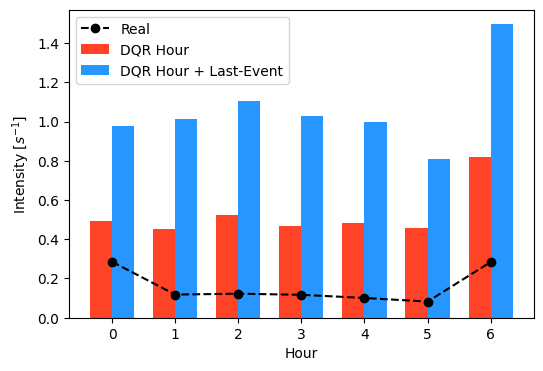

In [20]:
width = 0.35
x = hourly_dqr_h.index.values
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, hourly_dqr_h.values, width=width, color="#FF4327", label="DQR Hour")
ax.bar(x + width/2, hourly_dqr_h_le.values, width=width, color="#2797FF", label="DQR Hour + Last-Event")
ax.plot(x, hourly_real.values, "o--", color="black", label="Real")
#ax.hlines(hourly_qr, xmin=x.min() - 0.5, xmax=x.max() + 0.5, colors="black", linestyles="-", linewidth = 2, label="QR")
ax.set_xlabel("Hour")
ax.set_ylabel(r"Intensity [$s^{-1}$]")
ax.set_xticks(x)
ax.legend()
plt.show()

# EN TRAVAUX #

In [21]:
@torch.no_grad()
def predict_lambdas(model, data, batch_size=4096):
    model.eval()
    N = data["q"].shape[0]
    out = torch.empty((N, 3), dtype=torch.float32)

    for s in range(0, N, batch_size):
        q_batch = data["q"][s:s+batch_size]

        if model.use_hour and model.use_last_event:
            hour_batch = data["hour_id"][s:s+batch_size]
            last_event_batch = data["last_event"][s:s+batch_size]
            lambdas = model(q_batch, last_event=last_event_batch, hour=hour_batch)

        elif model.use_last_event:
            last_event_batch = data["last_event"][s:s+batch_size]
            lambdas = model(q_batch, last_event=last_event_batch)

        elif model.use_hour:
            hour_batch = data["hour_id"][s:s+batch_size]
            lambdas = model(q_batch, hour=hour_batch)

        else:
            lambdas = model(q_batch)

        out[s:s+batch_size] = lambdas.cpu()

    return out.numpy()


def balanced_accuracy_numpy(y_true, y_pred, n_classes=3):
    recalls = []
    for c in range(n_classes):
        mask = (y_true == c)
        if mask.sum() == 0:
            continue
        recalls.append((y_pred[mask] == c).mean())
    return float(np.mean(recalls))


def evaluate_dqr_model(model, data, eps=1e-12):
    lambdas = predict_lambdas(model, data)                 # shape (N,3)
    y_true = data["y"].cpu().numpy()
    dt_true = data["dt"].cpu().numpy()

    Lambda = lambdas.sum(axis=1)                          # total intensity
    chosen_lambda = lambdas[np.arange(len(y_true)), y_true]

    # 1) mean log-likelihood per observation (higher is better)
    loglik = np.mean(np.log(chosen_lambda + eps) - Lambda * dt_true)

    # 2) next-event prediction
    y_pred = np.argmax(lambdas, axis=1)
    bal_acc = balanced_accuracy_numpy(y_true, y_pred, n_classes=3)

    # 3) time-to-next-event relative difference
    # inferred from the exponential waiting time mean = 1 / Lambda
    dt_pred = 1.0 / np.maximum(Lambda, eps)
    rel_diff = np.mean(np.abs(dt_pred - dt_true) / np.maximum(dt_true, eps)) * 100.0

    return {
        "loglik": float(loglik),
        "bal_acc": float(bal_acc),
        "rel_diff_pct": float(rel_diff),
    }

In [22]:
def plot_figure3(results):
    model_names = list(results.keys())
    model_colors = {
        "Vanilla": "#1f77b4",
        "Hour": "#ff7f0e",
        "Last event": "#2ca02c",
        "Hour + Last event": "#d62728",
    }
    colors= [model_colors[m] for m in model_names]

    loglik = [results[m]["loglik"] for m in model_names]
    balacc = [results[m]["bal_acc"] for m in model_names]
    reldiff = [results[m]["rel_diff_pct"] for m in model_names]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

    axes[0].bar(model_names, loglik, color=colors)
    axes[0].set_title("Log-likelihood")
    axes[0].set_ylabel("Mean log-likelihood")
    axes[0].set_xlabel("(Higher is better)")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(model_names, balacc, color=colors)
    axes[1].set_title("Next event prediction\nBalanced accuracy")
    axes[1].set_ylabel("Balanced accuracy")
    axes[1].set_xlabel("(Higher is better)")
    axes[1].grid(axis="y", alpha=0.3)

    axes[2].bar(model_names, reldiff, color=colors)
    axes[2].set_title("Time to next event\n(Relative Difference (%))")
    axes[2].set_ylabel("Relative difference (%)")
    axes[2].set_xlabel("(Lower is better)")
    axes[2].grid(axis="y", alpha=0.3)

    for ax in axes:
        ax.tick_params(axis="x", rotation=20)

    plt.show()

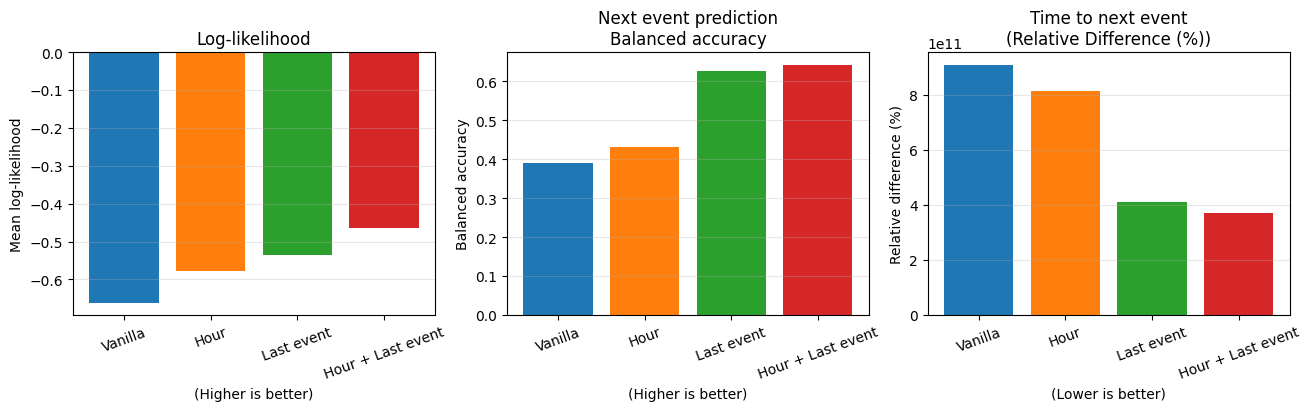

In [23]:
results = {
    "Vanilla": evaluate_dqr_model(model_vanilla, data_vanilla),
    "Hour": evaluate_dqr_model(model_hour, data_hour),
    "Last event": evaluate_dqr_model(model_last_event, data_last_event),
    "Hour + Last event": evaluate_dqr_model(model_hour_last_event, data_hour_last_event),
}

results
plot_figure3(results)